# D1 — E-commerce Customer Churn Prediction

## Objective
Predict which e-commerce customers are likely to churn and create a retention targeting rule.

## Dataset
E-commerce Customer Churn dataset.

## Target Variable
Churn

## Final Output
A trained churn prediction pipeline, evaluation metrics, threshold rule, and ranked high-risk customer list.

## 1.1 Import Libraries

In [248]:
pip install mlflow

In [249]:
import pandas as pd
import numpy as np
from sklearn.metrics import average_precision_score, f1_score, precision_score, recall_score, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, make_scorer
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, KFold
import mlflow
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
#from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

# 1. Load and Validate Dataset


## 1.1 Load Data and Confirm Correct Sheet

In [250]:
df = pd.ExcelFile('/content/E Commerce Dataset.xlsx')

In [251]:
df.sheet_names

['Data Dict', 'E Comm']

In [252]:
df_dict = pd.read_excel('/content/E Commerce Dataset.xlsx', sheet_name = 'Data Dict')
df_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


In [253]:
df_ecomm = pd.read_excel('/content/E Commerce Dataset.xlsx', sheet_name = 'E Comm')
df_ecomm

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


In [254]:
df_ecomm

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


In [255]:
df_ecomm.shape

(5630, 20)

In [256]:
df_ecomm.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='object')

## 1.2 Preview Shape, Columns, and Row Grain

## 1.3 Understand Column Meaning

In [257]:
df_dict

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3
0,NaN,Data,Variable,Discerption
1,NaN,E Comm,CustomerID,Unique customer ID
2,NaN,E Comm,Churn,Churn Flag
3,NaN,E Comm,Tenure,Tenure of customer in organization
4,NaN,E Comm,PreferredLoginDevice,Preferred login device of customer
5,NaN,E Comm,CityTier,City tier
6,NaN,E Comm,WarehouseToHome,Distance in between warehouse to home of customer
7,NaN,E Comm,PreferredPaymentMode,Preferred payment method of customer
8,NaN,E Comm,Gender,Gender of customer
9,NaN,E Comm,HourSpendOnApp,Number of hours spend on mobile application or...


# 2. Basic Data Quality Audit

## 2.1 Missingness, Data Types, Duplicates, Uniqueness

In [258]:
df_ecomm.dtypes

,0
CustomerID,int64
Churn,int64
Tenure,float64
PreferredLoginDevice,object
CityTier,int64
WarehouseToHome,float64
PreferredPaymentMode,object
Gender,object
HourSpendOnApp,float64
NumberOfDeviceRegistered,int64


In [259]:
for i in df_ecomm.columns:
  if 100.0*sum(df_ecomm[i].isna())/len(df_ecomm) > 0:
    print(i, ': ', round(100.0*sum(df_ecomm[i].isna())/len(df_ecomm), 2))

# the missingness is not much, from 4.5 to ~6% in just 7 columns
# Tenure, WarehouseToHome, HourSpendOnApp, OrderAmountHikeFromlastYear, CouponUsed, OrderCount, DaySinceLastOrder

Tenure :  4.69
WarehouseToHome :  4.46
HourSpendOnApp :  4.53
OrderAmountHikeFromlastYear :  4.71
CouponUsed :  4.55
OrderCount :  4.58
DaySinceLastOrder :  5.45


In [260]:
df_ecomm[df_ecomm.duplicated()]

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount


In [261]:
len(df_ecomm['CustomerID'])==df_ecomm['CustomerID'].nunique()

True

## 2.3 Numeric and Categorical Summary

In [262]:
cat_cols = ['PreferredLoginDevice', 'CityTier', 'PreferredPaymentMode', 'Gender', 'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore', 'MaritalStatus', 'Complain', 'CouponUsed', 'OrderCount']

num_cols = [i for i in df_ecomm.columns if i not in cat_cols]
for i in ['CustomerID', 'Churn']:
  num_cols.remove(i)
num_cols

df_ecomm_cat = df_ecomm[cat_cols]
df_ecomm_num = df_ecomm[num_cols]

In [263]:
df_ecomm_num.describe()

,Tenure,WarehouseToHome,HourSpendOnApp,NumberOfAddress,OrderAmountHikeFromlastYear,DaySinceLastOrder,CashbackAmount
count,5366.000000,5379.000000,5375.000000,5630.000000,5365.000000,5323.000000,5630.000000
mean,10.189899,15.639896,2.931535,4.214032,15.707922,4.543491,177.223030
std,8.557241,8.531475,0.721926,2.583586,3.675485,3.654433,49.207036
min,0.000000,5.000000,0.000000,1.000000,11.000000,0.000000,0.000000
25%,2.000000,9.000000,2.000000,2.000000,13.000000,2.000000,145.770000
50%,9.000000,14.000000,3.000000,3.000000,15.000000,3.000000,163.280000
75%,16.000000,20.000000,3.000000,6.000000,18.000000,7.000000,196.392500
max,61.000000,127.000000,5.000000,22.000000,26.000000,46.000000,324.990000


In [264]:
for i in df_ecomm_cat.columns:
  print(100.0*df_ecomm_cat[i].value_counts(normalize = True))

PreferredLoginDevice
Mobile Phone    49.111901
Computer        29.023091
Phone           21.865009
Name: proportion, dtype: float64
CityTier
1    65.115453
3    30.586146
2     4.298401
Name: proportion, dtype: float64
PreferredPaymentMode
Debit Card          41.101243
Credit Card         26.660746
E wallet            10.905861
UPI                  7.353464
COD                  6.483126
CC                   4.849023
Cash on Delivery     2.646536
Name: proportion, dtype: float64
Gender
Male      60.106572
Female    39.893428
Name: proportion, dtype: float64
NumberOfDeviceRegistered
4    42.220249
3    30.177620
5    15.648313
2     4.902309
1     4.174067
6     2.877442
Name: proportion, dtype: float64
PreferedOrderCat
Laptop & Accessory    36.412078
Mobile Phone          22.575488
Fashion               14.671403
Mobile                14.369449
Grocery                7.282416
Others                 4.689165
Name: proportion, dtype: float64
SatisfactionScore
3    30.159858
1    20.674956

# 3. Target Variable Analysis

## 3.2 Churn Distribution and Churn rate

In [265]:
100.0*df_ecomm['Churn'].value_counts(normalize = True)

# highly imbalanced target label

,proportion
Churn,
0,83.161634
1,16.838366


## 3.4 Class Imbalance Observation

## 3.5 Business Meaning of the Positive Class

# 4. Quick EDA for Churn Signals

## 4.1 Churn Rate by Key Categorical Features

In [266]:
target = 'Churn'

for col in cat_cols:
  print(df_ecomm.groupby(col)[target].agg(
              count="count",
              churn_count="sum",
              churn_rate="mean"
          ).sort_values("churn_rate", ascending=False))

                      count  churn_count  churn_rate
PreferredLoginDevice                                
Phone                  1231          276    0.224208
Computer               1634          324    0.198286
Mobile Phone           2765          348    0.125859
          count  churn_count  churn_rate
CityTier                                
3          1722          368    0.213705
2           242           48    0.198347
1          3666          532    0.145117
                      count  churn_count  churn_rate
PreferredPaymentMode                                
COD                     365          105    0.287671
E wallet                614          140    0.228013
CC                      273           59    0.216117
UPI                     414           72    0.173913
Cash on Delivery        149           23    0.154362
Debit Card             2314          356    0.153846
Credit Card            1501          193    0.128581
        count  churn_count  churn_rate
Gender        

## 4.2 Numeric Feature Differences by Churn Status

In [267]:
for i in num_cols:
  print(df_ecomm.groupby(target)[i].median())

Churn
0    10.0
1     1.0
Name: Tenure, dtype: float64
Churn
0    13.0
1    15.0
Name: WarehouseToHome, dtype: float64
Churn
0    3.0
1    3.0
Name: HourSpendOnApp, dtype: float64
Churn
0    3.0
1    3.0
Name: NumberOfAddress, dtype: float64
Churn
0    15.0
1    14.0
Name: OrderAmountHikeFromlastYear, dtype: float64
Churn
0    4.0
1    2.0
Name: DaySinceLastOrder, dtype: float64
Churn
0    166.115
1    149.660
Name: CashbackAmount, dtype: float64


## 4.3 Early Leakage / Non-Predictive Column Check

In [268]:
df_ecomm

# no leakage specific columns seem to exist

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,55626,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,55627,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,55628,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,55629,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


# 5. Preprocessing and Train-Test Split

## 5.1 Define Features, Target, and Dropped Columns

In [269]:
# dropped columns: CustomerID
# target: Churn

df_ecomm.drop('CustomerID', axis = 1, inplace = True)


## 5.2 Imputation, Encoding, and Scaling Plan

In [270]:
# cols_bin = ['HourSpendOnApp', 'WarehouseToHome', 'NumberOfAddress', 'OrderAmountHikeFromlastYear', 'CouponUsed', 'CashbackAmount', 'OrderCount', 'DaySinceLastOrder']
cols_ohe = ['Gender', 'PreferredPaymentMode', 'PreferredLoginDevice', 'PreferedOrderCat', 'MaritalStatus']

# Tenure :  4.69
# WarehouseToHome :  4.46
# HourSpendOnApp :  4.53
# OrderAmountHikeFromlastYear :  4.71
# CouponUsed :  4.55
# OrderCount :  4.58
# DaySinceLastOrder :  5.45

# median: WarehouseToHome, HourSpendOnApp, DaySinceLastOrder, OrderCount, CouponUsed, OrderAmountHikeFromlastYear, HourSpendOnApp, WarehouseToHome, Tenure
cols_num = ['WarehouseToHome', 'HourSpendOnApp', 'DaySinceLastOrder', 'OrderCount', 'CouponUsed', 'OrderAmountHikeFromlastYear', 'HourSpendOnApp', 'WarehouseToHome', 'Tenure']

# we can bin HourSpendOnApp, WarehouseToHome, NumberOfAddress, OrderAmountHikeFromlastYear, CouponUsed, CashbackAmount, OrderCount, DaySinceLastOrder
# One Hot Encoding: Gender, PreferredPaymentMode, PreferredLoginDevice, PreferedOrderCat, MaritalStatus

# standardscaling for logisticregression

## 5.3 Stratified Train-Test Split

In [271]:
df_ecomm

,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5625,0,10.0,Computer,1,30.0,Credit Card,Male,3.0,2,Laptop & Accessory,1,Married,6,0,18.0,1.0,2.0,4.0,150.71
5626,0,13.0,Mobile Phone,1,13.0,Credit Card,Male,3.0,5,Fashion,5,Married,6,0,16.0,1.0,2.0,NaN,224.91
5627,0,1.0,Mobile Phone,1,11.0,Debit Card,Male,3.0,2,Laptop & Accessory,4,Married,3,1,21.0,1.0,2.0,4.0,186.42
5628,0,23.0,Computer,3,9.0,Credit Card,Male,4.0,5,Laptop & Accessory,4,Married,4,0,15.0,2.0,2.0,9.0,178.90


In [272]:
y = df_ecomm['Churn']
X = df_ecomm.drop('Churn', axis = 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

# 6. Baseline Modeling



## 6.1 Logistic Regression



In [273]:
# basic logistic regression

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown= 'ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, cols_num),
    ('cat', cat_pipe, cols_ohe)
])

pipe_logreg = Pipeline([
    ('preprocessor', preprocessor),
    ('logreg', LogisticRegression(class_weight = 'balanced', max_iter = 1000))
])

logreg = pipe_logreg.fit(X_train, y_train)

y_pred_logreg = logreg.predict(X_test)
y_pred_proba_logreg = logreg.predict_proba(X_test)[:,1]

## 6.2 Random Forest



In [274]:
ranfor = RandomForestClassifier() # + class_weight variant

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median')),
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, cols_num),
    ('cat', cat_pipe, cols_ohe)
])

pipe_ranfor = Pipeline([
    ('preprocessor', preprocessor),
    ('ranfor', RandomForestClassifier(class_weight = 'balanced'))
])

ranfor = pipe_ranfor.fit(X_train, y_train)

y_pred_ranfor = ranfor.predict(X_test)
y_pred_proba_ranfor = ranfor.predict_proba(X_test)[:,1]

## 6.3 XGBoost



In [275]:
scale_pos_weight = len(df_ecomm[df_ecomm['Churn']==0])/len(df_ecomm[df_ecomm['Churn']==1])

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'median'))
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy = 'most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, cols_num),
    ('cat', cat_pipe, cols_ohe)
])

pipe_xgbc = Pipeline([
    ('preprocessor', preprocessor),
    ('xgbc', XGBClassifier(scale_pos_weight = scale_pos_weight))
])

xgbc = pipe_xgbc.fit(X_train, y_train)

y_pred_xgbc = xgbc.predict(X_test)
y_pred_proba_xgbc = xgbc.predict_proba(X_test)[:,1]

## 6.4 Imbalance Handling

# 7. Model Evaluation



## 7.1 ROC-AUC and PR-AUC Comparison



In [276]:
# roc auc score
print('LOGISTIC REGRESSION - ROC AUC SCORE - PRECISION RECALL SCORE')
print(round(roc_auc_score(y_test, y_pred_proba_logreg), 2), round(average_precision_score(y_test, y_pred_proba_logreg), 2))

print('RANDOM FOREST - ROC AUC SCORE - PRECISION RECALL SCORE')
print(round(roc_auc_score(y_test, y_pred_proba_ranfor), 2), round(average_precision_score(y_test, y_pred_proba_ranfor), 2))

print('XGBOOST - ROC AUC SCORE - PRECISION RECALL SCORE')
print(round(roc_auc_score(y_test, y_pred_proba_xgbc), 2), round(average_precision_score(y_test, y_pred_proba_xgbc), 2))

LOGISTIC REGRESSION - ROC AUC SCORE - PRECISION RECALL SCORE
0.83 0.56
RANDOM FOREST - ROC AUC SCORE - PRECISION RECALL SCORE
0.98 0.93
XGBOOST - ROC AUC SCORE - PRECISION RECALL SCORE
0.98 0.93


In [277]:
# random forest is evidently scoring the best on pr score and roc auc score

## 7.2 Precision, Recall, and F1 Comparison



In [278]:
# precision score

print('LOGISTIC REGRESSION - PRECISION SCORE - RECALL SCORE - F1 SCORE')
print(round(precision_score(y_test, y_pred_logreg), 2), round(recall_score(y_test, y_pred_logreg), 2), round(f1_score(y_test, y_pred_logreg), 2))

print('RANDOM FOREST - PRECISION SCORE - RECALL SCORE - F1 SCORE')
print(round(precision_score(y_test, y_pred_ranfor), 2), round(recall_score(y_test, y_pred_ranfor), 2), round(f1_score(y_test, y_pred_ranfor), 2))

print('XGBOOST - PRECISION SCORE - RECALL SCORE - F1 SCORE')
print(round(precision_score(y_test, y_pred_xgbc), 2), round(recall_score(y_test, y_pred_xgbc), 2), round(f1_score(y_test, y_pred_xgbc), 2))

LOGISTIC REGRESSION - PRECISION SCORE - RECALL SCORE - F1 SCORE
0.37 0.79 0.51
RANDOM FOREST - PRECISION SCORE - RECALL SCORE - F1 SCORE
0.95 0.68 0.8
XGBOOST - PRECISION SCORE - RECALL SCORE - F1 SCORE
0.84 0.92 0.88


In [279]:
# evidently, collectively xgboost scores best on precision, recall, and f1 score alone

## 7.3 Confusion Matrix Review



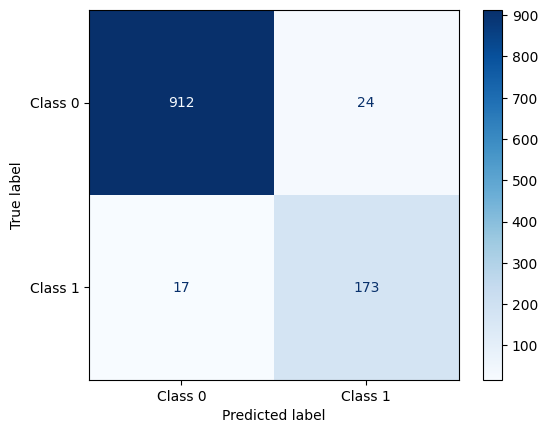

In [280]:
cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

## 7.4 Select Best Baseline Model

In [281]:
# xgboost is the clear champion with the best recall which is the primary important metric in a churn situation according to business
# objectives

# 8. Threshold Tuning and Retention Rule



In [282]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba_xgbc >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        "customers_flagged": y_pred_threshold.sum(),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,threshold,precision,recall,f1,customers_flagged,true_positives,false_positives,false_negatives,true_negatives
0,0.2,0.682836,0.963158,0.799127,268,183,85,7,851
1,0.3,0.759336,0.963158,0.849188,241,183,58,7,878
2,0.4,0.810811,0.947368,0.873786,222,180,42,10,894
3,0.5,0.837321,0.921053,0.877193,209,175,34,15,902
4,0.6,0.878173,0.910526,0.894057,197,173,24,17,912
5,0.7,0.898876,0.842105,0.869565,178,160,18,30,918


## 8.1 Precision-Recall Tradeoff



## 8.2 Choose Retention Targeting Threshold



In [283]:
selected_threshold = 0.60

y_pred_final = (y_pred_proba_xgbc >= selected_threshold).astype(int)

# I selected 0.60 as the retention targeting threshold because it gives the best F1 score while maintaining very high recall. Compared
# to 0.40, it improves precision meaningfully while only slightly reducing recall, creating a cleaner high-risk customer list for
# retention action.

## 8.3 Create Churn Risk Buckets

In [284]:
scored_test = X_test.copy()

scored_test["actual_churn"] = y_test.values
scored_test["churn_probability"] = y_pred_proba_xgbc
scored_test["predicted_churn"] = y_pred_final

scored_test["risk_bucket"] = pd.cut(
    scored_test["churn_probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    include_lowest=True
)

scored_test.head()

,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,...,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,actual_churn,churn_probability,predicted_churn,risk_bucket
4006,17.0,Computer,3,9.0,Debit Card,Male,4.0,4,Laptop & Accessory,1,...,0,21.0,6.0,8.0,8.0,181.75,0,0.000293,0,Low Risk
1969,26.0,Mobile Phone,3,13.0,E wallet,Female,3.0,4,Fashion,1,...,1,18.0,0.0,1.0,NaN,209.34,0,0.000123,0,Low Risk
4235,5.0,Mobile Phone,1,15.0,Debit Card,Female,4.0,4,Laptop & Accessory,1,...,0,24.0,2.0,2.0,9.0,169.24,0,0.015732,0,Low Risk
105,25.0,Phone,1,8.0,Debit Card,Female,2.0,4,Mobile,2,...,0,15.0,0.0,2.0,2.0,132.12,0,0.000164,0,Low Risk
2295,4.0,Computer,3,8.0,Debit Card,Female,2.0,3,Fashion,3,...,1,19.0,8.0,9.0,6.0,198.52,0,0.000735,0,Low Risk


# 9. Segment Error Analysis



## 9.1 False Positives and False Negatives



In [285]:
def error_type(row):
    if row["actual_churn"] == 1 and row["predicted_churn"] == 1:
        return "True Positive"
    elif row["actual_churn"] == 0 and row["predicted_churn"] == 1:
        return "False Positive"
    elif row["actual_churn"] == 1 and row["predicted_churn"] == 0:
        return "False Negative"
    else:
        return "True Negative"

scored_test["error_type"] = scored_test.apply(error_type, axis=1)

scored_test["error_type"].value_counts()

,count
error_type,
True Negative,912
True Positive,173
False Positive,24
False Negative,17


## 9.2 Error Patterns by Tenure, Complaint, Satisfaction, and Order Behavior



In [286]:
pd.crosstab(scored_test["Tenure"], scored_test["error_type"])

error_type,False Negative,False Positive,True Negative,True Positive
Tenure,,,,
0.0,3,7,38,47
1.0,8,14,46,61
2.0,0,0,35,5
3.0,0,0,37,4
4.0,0,0,50,8
5.0,2,1,34,1
6.0,0,0,27,1
7.0,0,0,40,2
8.0,0,0,50,3


In [287]:
pd.crosstab(scored_test["Complain"], scored_test["error_type"])

error_type,False Negative,False Positive,True Negative,True Positive
Complain,,,,
0,7,20,682,75
1,10,4,230,98


In [288]:
pd.crosstab(scored_test["SatisfactionScore"], scored_test["error_type"])

error_type,False Negative,False Positive,True Negative,True Positive
SatisfactionScore,,,,
1,2,8,180,27
2,2,2,114,16
3,8,4,300,50
4,1,4,146,34
5,4,6,172,46


In [289]:
pd.crosstab(scored_test["OrderCount"], scored_test["error_type"])

error_type,False Negative,False Positive,True Negative,True Positive
OrderCount,,,,
1.0,7,10,278,57
2.0,5,8,315,67
3.0,3,4,59,7
4.0,0,2,32,4
5.0,0,0,30,2
6.0,0,0,28,4
7.0,0,0,35,13
8.0,0,0,30,5
9.0,0,0,12,0


In [290]:
pd.crosstab(scored_test["DaySinceLastOrder"], scored_test["error_type"])

error_type,False Negative,False Positive,True Negative,True Positive
DaySinceLastOrder,,,,
0.0,5,6,60,37
1.0,0,6,78,33
2.0,3,4,137,17
3.0,1,5,148,17
4.0,1,3,83,11
5.0,0,0,40,7
6.0,0,0,16,3
7.0,2,0,65,15
8.0,3,0,91,12


## 9.3 Key Model Weaknesses

The model performs strongly overall, but remaining false negatives are important because they represent churned customers the model failed to flag. Error patterns should be reviewed across tenure, complaint status, satisfaction score, order count, and days since last order before using the model for retention targeting. These patterns can help identify customer groups where the model is less reliable.

# 10. Sprint Output



## 10.1 Save Final Pipeline



In [291]:
import joblib
import json
import os

os.makedirs("outputs", exist_ok=True)
os.makedirs("models", exist_ok=True)

joblib.dump(xgbc, "models/d1_xgboost_churn_model.pkl")

threshold_policy = {
    "selected_threshold": selected_threshold,
    "reason": "Best F1 score with high recall and improved precision for retention targeting."
}

with open("outputs/threshold_policy.json", "w") as f:
    json.dump(threshold_policy, f, indent=4)

## 10.2 Save Metrics and Threshold Policy



In [292]:
threshold_df.to_csv("outputs/threshold_scan.csv", index=False)

## 10.3 Save Scored High-Risk Customers

In [293]:
scored_test.to_csv("outputs/scored_test_customers.csv", index=False)

## 10.4 MLflow Logging

In [294]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

mlflow.set_experiment("D1_Ecommerce_Churn_Prediction")

with mlflow.start_run(run_name="xgboost_churn_champion"):

    # log model info
    mlflow.log_param("model", "XGBoost")
    mlflow.log_param("selected_threshold", selected_threshold)
    mlflow.log_param("business_use_case", "retention_targeting")

    # log test metrics using final threshold
    mlflow.log_metric("roc_auc", roc_auc_score(y_test, y_pred_proba_xgbc))
    mlflow.log_metric("pr_auc", average_precision_score(y_test, y_pred_proba_xgbc))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_final))
    mlflow.log_metric("recall", recall_score(y_test, y_pred_final))
    mlflow.log_metric("f1", f1_score(y_test, y_pred_final))

    # log final model/pipeline
    mlflow.sklearn.log_model(xgbc, "model")

    # log output files if already saved
    mlflow.log_artifact("outputs/threshold_scan.csv")
    mlflow.log_artifact("outputs/scored_test_customers.csv")
    mlflow.log_artifact("outputs/threshold_policy.json")

2026/05/03 19:25:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 19:25:09 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 19:25:12 INFO mlflow.tracking.fluent: Experiment with name 'D1_Ecommerce_Churn_Prediction' does not exist. Creating a new experiment.
2026/05/03 19:25:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 19:25:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


# 11. Final Business Summary



## 11.1 What Was Built



Built a churn prediction model to identify e-commerce customers likely to churn and prioritize them for retention targeting. Logistic Regression, Random Forest, and XGBoost were compared using ROC-AUC, PR-AUC, precision, recall, and F1. XGBoost was selected as the champion model because it achieved strong PR-AUC with the best recall/F1 balance. A threshold of 0.60 was selected to create a cleaner high-risk customer list while still capturing most churners. The output is a scored customer file with churn probability, predicted churn label, and risk bucket.

## 11.2 Best Model and Metrics



XGBoost was selected as the champion model because it gave the strongest overall balance for churn targeting.

At the default comparison stage, XGBoost achieved strong ROC-AUC and PR-AUC, with much higher recall than Random Forest. After threshold tuning, a cutoff of `0.60` was selected because it produced the best F1 score while maintaining high recall and improving precision.

Final threshold performance at `0.60`:

- Precision: `0.88`
- Recall: `0.91`
- F1 Score: `0.89`
- Customers flagged: `197`
- True positives: `173`
- False positives: `24`
- False negatives: `17`

## 11.3 Business Recommendation



Use the XGBoost churn score to rank customers by churn risk and prioritize retention outreach.

For this sprint, customers with churn probability `>= 0.60` should be treated as high-risk and included in the retention targeting list. This threshold keeps recall high while reducing unnecessary outreach compared to lower thresholds.

The model should be used as a ranking and prioritization tool, not as a causal explanation of churn. Before real deployment, the threshold should be adjusted based on actual retention team capacity, campaign cost, and intervention results.

## 11.4 Limitations and Next Improvements

This model is useful for churn risk ranking, not causal explanation. The dataset is static, there is no retention intervention outcome data, and the selected threshold should be adjusted based on real outreach capacity and campaign cost.